# Net-Payout-Based Duration

## 0. Setup, Imports, Paths, Session


In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from pathlib import Path
from plot_style import COLORS, set_global_plot_style, style_axes

set_global_plot_style()

# Speicherstruktur fuer Intermediate und Final Output
from project_paths import BASE_DIR, DATA_DIR, CACHE_DATA_DIR

def save_parquet(df: pd.DataFrame, name: str):
    path = DATA_DIR / f"{name}.parquet"
    df.to_parquet(path, index=False)
    print(f"Saved: {path}")

def load_parquet(name: str) -> pd.DataFrame:
    path = DATA_DIR / f"{name}.parquet"
    return pd.read_parquet(path)


## 2. Master Panel Construction


In [2]:
# Load annual duration input table (full-history saved as euro500_netpayout)
duration_input = load_parquet("euro500_netpayout").copy()

if "firm_id" not in duration_input.columns:
    raise KeyError("euro500_netpayout must contain firm_id")

# Ensure Module D field is present already at Step 1 input stage.
if "CashSTInvst" not in duration_input.columns:
    duration_input["CashSTInvst"] = np.nan

# Derive year from the annual observation date (fallback: effective_date)
if "date" in duration_input.columns:
    duration_input["date"] = pd.to_datetime(duration_input["date"], errors="coerce")
    duration_input["year"] = duration_input["date"].dt.year
elif "effective_date" in duration_input.columns:
    duration_input["effective_date"] = pd.to_datetime(duration_input["effective_date"], errors="coerce")
    duration_input["year"] = duration_input["effective_date"].dt.year
elif "year" not in duration_input.columns:
    raise KeyError("euro500_netpayout needs date, effective_date, or year")

# Quarterly EURO500 panel is only the mapping target for final output.
base_euro500 = load_parquet("euro500").copy()
if "firm_id" not in base_euro500.columns:
    raise KeyError("euro500 must contain firm_id")

euro500_netpayout = duration_input.copy()

print(
    f"Loaded annual duration input (euro500_netpayout): rows={len(duration_input):,}, "
    f"firm_id={duration_input['firm_id'].nunique():,}"
)
print(
    f"Loaded quarterly mapping base (euro500): rows={len(base_euro500):,}, "
    f"firm_id={base_euro500['firm_id'].nunique():,}"
)
print("Step 1 check: CashSTInvst in duration input =", "CashSTInvst" in duration_input.columns)


Loaded annual duration input (euro500_netpayout): rows=16,872, firm_id=1,125
Loaded quarterly mapping base (euro500): rows=56,500, firm_id=1,248
Step 1 check: CashSTInvst in duration input = True


### 2.1 Firm-Year Master Panel (ME, BE, Assets, Sales, NI, GP, Debt, Dividends, Buybacks, CashSTInvst)


In [3]:
def build_masterpanel_firmyear(euro500_netpayout):
    """
    Build one row per firm_id-year for valuation/state construction.
    Keeps firm metadata (name) and accounting/value fields.
    """
    df = euro500_netpayout.copy()

    df["firm_id"] = df["firm_id"].astype(str).str.strip()
    df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
    df = df.dropna(subset=["firm_id", "year"]).copy()
    df["year"] = df["year"].astype(int)

    for dt_col in ["date", "effective_date"]:
        if dt_col in df.columns:
            df[dt_col] = pd.to_datetime(df[dt_col], errors="coerce")

    rename_map = {
        "mcap_eur": "ME",
        "Sales": "sales",
        "NetIncome": "net_income",
        "GrossProfit": "gross_profit",
        "Dividends": "dividends",
        "Buybacks": "buybacks",
    }
    existing_renames = {k: v for k, v in rename_map.items() if k in df.columns}
    if existing_renames:
        df = df.rename(columns=existing_renames)

    cols = [
        "firm_id", "name", "year", "date", "effective_date",
        "ME", "BE", "assets", "sales", "net_income", "gross_profit", "debt",
        "dividends", "buybacks", "CashSTInvst",
    ]
    cols = [c for c in cols if c in df.columns]
    df = df[cols].copy()

    value_cols = [
        c for c in [
            "ME", "BE", "assets", "sales", "net_income", "gross_profit", "debt", "dividends", "buybacks", "CashSTInvst"
        ] if c in df.columns
    ]
    for c in value_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # one row per firm-year from annual input: prefer year-end observation (latest date in year)
    dedupe_date_cols = [c for c in ["date", "effective_date"] if c in df.columns]
    sort_cols = ["firm_id", "year"] + dedupe_date_cols
    df = df.sort_values(sort_cols)
    df = df.drop_duplicates(subset=["firm_id", "year"], keep="last").reset_index(drop=True)

    df["dividends"] = df["dividends"].fillna(0.0) if "dividends" in df.columns else 0.0
    df["buybacks"] = df["buybacks"].fillna(0.0) if "buybacks" in df.columns else 0.0
    df["PO"] = df["dividends"] + df["buybacks"]

    df = df.sort_values(["firm_id", "year"]).reset_index(drop=True)
    lag_vars = [
        c for c in ["ME", "BE", "assets", "sales", "net_income", "gross_profit", "debt", "dividends", "buybacks", "CashSTInvst", "PO"]
        if c in df.columns
    ]
    for c in lag_vars:
        df[f"{c}_lag1"] = df.groupby("firm_id")[c].shift(1)

    df["dBE"] = df["BE"] - df["BE_lag1"]
    df["avgBE"] = 0.5 * (df["BE"] + df["BE_lag1"])
    df["avgAssets"] = 0.5 * (df["assets"] + df["assets_lag1"])

    df.loc[df["ME"] <= 0, "ME"] = pd.NA
    df.loc[df["BE"] <= 0, "BE"] = pd.NA
    df.loc[df["assets"] <= 0, "assets"] = pd.NA
    df.loc[df["sales"] <= 0, "sales"] = pd.NA
    df.loc[df["debt"] < 0, "debt"] = pd.NA

    return df




In [4]:
master = build_masterpanel_firmyear(euro500_netpayout)

master.head()

,firm_id,name,year,date,effective_date,ME,BE,assets,sales,net_income,...,net_income_lag1,gross_profit_lag1,debt_lag1,dividends_lag1,buybacks_lag1,CashSTInvst_lag1,PO_lag1,dBE,avgBE,avgAssets
0,FIRM0000001,<NA>,1998,1998-11-30,NaT,<NA>,92670119.59117,201941375.2729,296097820.36271,15384772.70519,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,FIRM0000001,<NA>,1999,1999-11-30,NaT,<NA>,104237075.81947,264407949.56617,305313856.52127,15307056.33925,...,15384772.70519,145027942.10131,54100816.53313,10021320.87145,0.0,20117801.64943,10021320.87145,11566956.2283,98453597.70532,233174662.419535
2,FIRM0000001,<NA>,2000,2000-11-30,NaT,<NA>,108772234.80568,265103817.81648,379503331.06661,14892398.6236,...,15307056.33925,148917850.73345,101319133.05349,0.0,0.0,39481959.06597,0.0,4535158.98621,106504655.312575,264755883.691325
3,FIRM0000001,<NA>,2001,2001-11-30,NaT,<NA>,108458000.0,259187000.0,379731000.0,12857000.0,...,14892398.6236,184504276.95659,99152278.06098,11046972.38513,0.0,21139362.82806,11046972.38513,-314234.80568,108615117.40284,262145408.90824
4,FIRM0000001,<NA>,2002,2002-11-30,NaT,<NA>,107209000.0,251266000.0,350488000.0,12126000.0,...,12857000.0,183741000.0,94053000.0,11888000.0,0.0,28166000.0,11888000.0,-1249000.0,107833500.0,255226500.0


## 3. Data Validity Checks

Before constructing state variables, this section checks whether all denominator and transformation conditions are valid (e.g., positivity for log terms and `1+x>0` for `log1p`).

Potential violations are rare, so only a small share of observations is excluded through the `safe_log` / `safe_log1p` guards.


In [5]:
checks = pd.DataFrame({
    
    # valuation
    "ME<=0": (master["ME"] <= 0),
    "BE<=0": (master["BE"] <= 0),
    "sales<=0": (master["sales"] <= 0),
    
    # growth
    "BE_lag1<=0": (master["BE_lag1"] <= 0),
    "assets_lag1<=0": (master["assets_lag1"] <= 0),
    "sales_lag1<=0": (master["sales_lag1"] <= 0),

    # profitability denominators
    "avgBE<=0": (master["avgBE"] <= 0),
    "avgAssets<=0": (master["avgAssets"] <= 0),

    # log1p conditions
    "1+PO/ME<=0": (1 + master["PO"]/master["ME"] <= 0),
    "1+(PO+dBE)/BE_lag1<=0": (1 + (master["PO"] + master["dBE"]) / master["BE_lag1"] <= 0),
    "1+NI/avgBE<=0": (1 + master["net_income"] / master["avgBE"] <= 0),
    "1+GP/avgAssets<=0": (1 + master["gross_profit"] / master["avgAssets"] <= 0),

    # leverage denominator
    "debt+ME<=0": (master["debt"] + master["ME"] <= 0),
})

checks.mean().sort_values(ascending=False)

BE_lag1<=0               0.008898
avgBE<=0                 0.007264
1+(PO+dBE)/BE_lag1<=0    0.007199
1+NI/avgBE<=0            0.005696
sales_lag1<=0            0.003243
1+PO/ME<=0               0.000983
1+GP/avgAssets<=0        0.000221
ME<=0                         0.0
BE<=0                         0.0
sales<=0                      0.0
assets_lag1<=0                0.0
avgAssets<=0                  0.0
debt+ME<=0                    0.0
dtype: Float64

## 4. Construction of Firm-Level State Variables


In this step, we construct the firm-level state variables used in the pooled VAR(1).

The state vector contains exactly 12 variables:
- `bm`, `py`, `sy`, `beg`, `ag`, `sg`, `csprof`, `roe`, `gp`, `lev`, `blev`, `cash`

The clean-surplus profitability definition is:
$$
csprof_{i,t} = \log\left(1 + \frac{PO_{i,t} + \Delta BE_{i,t}}{BE_{i,t-1}}\right).
$$

At this stage, variables are constructed from raw accounting/market inputs; winsorization is applied in Step 4.


In [6]:
def build_state_variables(master):
    df = master.copy()

    def safe_log(x):
        x = pd.to_numeric(x, errors="coerce")
        out = pd.Series(np.nan, index=df.index, dtype=float)
        m = x > 0
        out.loc[m] = np.log(x.loc[m])
        return out

    def safe_log1p(x):
        x = pd.to_numeric(x, errors="coerce")
        out = pd.Series(np.nan, index=df.index, dtype=float)
        m = x > -1  # log(1+x) defined iff 1+x > 0
        out.loc[m] = np.log1p(x.loc[m])
        return out

    # Ensure numeric inputs
    num_cols = [
        "BE", "ME", "PO", "sales",
        "BE_lag1", "assets", "assets_lag1", "sales_lag1",
        "dBE", "net_income", "avgBE", "gross_profit", "avgAssets",
        "debt", "CashSTInvst"
    ]
    for col in num_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # Valuation
    df["bm"] = safe_log(df["BE"] / df["ME"])
    df["py"] = safe_log1p(df["PO"] / df["ME"])
    df["sy"] = safe_log(df["sales"] / df["ME"])

    # Growth
    df["beg"] = safe_log(df["BE"] / df["BE_lag1"])
    df["ag"]  = safe_log(df["assets"] / df["assets_lag1"])
    df["sg"]  = safe_log(df["sales"] / df["sales_lag1"])

    # Profitability
    csprof_raw = (df["PO"] + df["dBE"]) / df["BE_lag1"]
    roe_raw    = df["net_income"] / df["avgBE"]
    gp_raw     = df["gross_profit"] / df["avgAssets"]

    # Optional paper-near floor so log1p stays well-defined
    csprof_raw = csprof_raw.clip(lower=-0.99)
    roe_raw    = roe_raw.clip(lower=-0.99)
    gp_raw     = gp_raw.clip(lower=-0.99)

    df["csprof"] = safe_log1p(csprof_raw)
    df["roe"]    = safe_log1p(roe_raw)
    df["gp"]     = safe_log1p(gp_raw)

    # Capital structure: book leverage and cash holdings
    assets = df["assets"].to_numpy(dtype=float)
    debt   = df["debt"].to_numpy(dtype=float)
    cash   = df["CashSTInvst"].to_numpy(dtype=float)
    me     = df["ME"].to_numpy(dtype=float)

    blev = np.full(len(df), np.nan, dtype=float)
    cash_ratio = np.full(len(df), np.nan, dtype=float)

    mask_assets = assets > 0
    blev[mask_assets] = debt[mask_assets] / assets[mask_assets]
    cash_ratio[mask_assets] = cash[mask_assets] / assets[mask_assets]

    df["blev"] = blev
    df["cash"] = cash_ratio

    # Capital structure: market leverage
    denom = debt + me
    lev = np.full(len(df), np.nan, dtype=float)
    mask_lev = denom > 0
    lev[mask_lev] = debt[mask_lev] / denom[mask_lev]
    df["lev"] = lev

    # Final state variable set
    state_vars = [
        "bm", "py", "sy",
        "beg", "ag", "sg",
        "csprof", "roe", "gp",
        "lev", "blev", "cash"
    ]

    df[state_vars] = df[state_vars].replace([np.inf, -np.inf], np.nan)

    return df

In [7]:
state_panel = build_state_variables(master)

In [8]:
state_vars = [
    "bm","py","sy",
    "beg","ag","sg",
    "csprof","roe","gp",
    "lev","blev","cash"
]

state_panel[state_vars].isna().mean().sort_values(ascending=False)
state_panel[state_vars].describe(percentiles=[0.01,0.05,0.5,0.95,0.99]).T

,count,mean,std,min,1%,5%,50%,95%,99%,max
bm,9066.0,-0.615910,0.831503,-8.299590,-2.834880,-2.019281,-0.553624,0.601400,1.240887,2.547247
py,9148.0,0.014625,0.109055,-3.303208,-0.344478,-0.069635,0.020262,0.091330,0.168581,0.967096
sy,8922.0,-0.229777,1.313825,-12.036174,-3.989174,-2.347423,-0.115550,1.654159,2.359146,4.281099
beg,15375.0,0.107906,0.394067,-5.970282,-0.690366,-0.217320,0.070404,0.553919,1.514700,10.305992
ag,15651.0,0.097594,0.300257,-4.919704,-0.394355,-0.133434,0.056615,0.462157,1.093414,10.568188
sg,15324.0,0.083356,0.396916,-8.357161,-0.847749,-0.242388,0.062773,0.472071,1.130002,7.695724
csprof,15554.0,0.097148,0.536995,-4.605170,-1.617855,-0.233624,0.115713,0.485956,1.155878,10.305992
roe,15273.0,0.085459,0.429674,-4.605170,-1.058886,-0.155263,0.115743,0.342072,0.657026,5.364771
gp,13546.0,0.278859,0.216299,-4.605170,0.000000,0.038672,0.241242,0.663221,0.966774,1.656442
lev,8950.0,0.321305,0.236728,0.000000,0.000247,0.007879,0.286093,0.769865,0.897254,0.981707


In [9]:
state_panel.groupby("year")[state_vars].count().tail()

,bm,py,sy,beg,ag,sg,csprof,roe,gp,lev,blev,cash
year,,,,,,,,,,,,
2021,472,477,469,567,576,565,576,568,499,474,585,574
2022,32,33,33,546,554,544,554,546,478,33,568,558
2023,17,17,17,538,550,539,550,542,473,17,559,548
2024,461,465,456,529,535,523,535,527,457,462,534,522
2025,28,28,28,38,38,38,38,38,36,28,38,38


## 5. Winsorizing State Variables

State variables are winsorized by year at the 1st and 99th percentiles for robustness before VAR estimation.


In [10]:
# ============================================================
# Winsorize State Variables by YEAR (1% / 99%)
# ============================================================

STATE_VARS_WINSOR = [
    "bm", "py", "sy",
    "beg", "ag", "sg",
    "csprof", "roe", "gp"
]

def winsorize_by_year(df, cols, year_col="year", lower=0.01, upper=0.99):
    
    df = df.copy()
    
    for col in cols:
        
        lower_bound = df.groupby(year_col)[col].transform(
            lambda x: x.quantile(lower)
        )
        
        upper_bound = df.groupby(year_col)[col].transform(
            lambda x: x.quantile(upper)
        )
        
        df[col] = df[col].clip(lower_bound, upper_bound)
    
    return df


state_panel = winsorize_by_year(
    state_panel,
    STATE_VARS_WINSOR,
    year_col="year"
)

## 6. Estimation of the Firm-Level State VAR

We estimate a pooled VAR(1) on the 12-dimensional state vector using equation-by-equation OLS, without state standardization.

Model form:
$$
x_{t+1} = c + \Phi x_t + u_{t+1}.
$$

The implementation includes a stability check via eigenvalues of `Phi` and forecasting utilities based on the same raw-state transition equation.


In [11]:
# ============================================================
# STEP 5: Firm-Level State VAR(1) + forecasting utilities
# (paper-near implementation, no standardization)
# ============================================================


# ----------------------------
# 5.1 Full state vector
# ----------------------------
var_states = [
    "bm", "py", "sy",
    "beg", "ag", "sg",
    "csprof", "roe", "gp",
    "lev", "blev", "cash"
]

# choose your time column here
TIME_COL = "year"

# ----------------------------
# 5.2 Build VAR sample (t -> t+1)
# ----------------------------
df_var = state_panel.sort_values(["firm_id", TIME_COL]).copy()

# create one-period-ahead leads
for v in var_states:
    df_var[f"{v}_lead"] = df_var.groupby("firm_id")[v].shift(-1)

# keep only rows where all states exist at t and t+1
req_cols = var_states + [f"{v}_lead" for v in var_states]
df_var = df_var.dropna(subset=req_cols).copy()

# optional: minimum time-series length per firm
min_T = 10
firm_counts = df_var.groupby("firm_id").size()
valid_firms = firm_counts[firm_counts >= min_T].index
df_var = df_var[df_var["firm_id"].isin(valid_firms)].copy()

print("STEP 5 VAR sample:")
print(f"  firms: {df_var['firm_id'].nunique()}")
print(f"  obs  : {len(df_var)}")

# ----------------------------
# 5.3 Estimate pooled VAR(1) equation by equation
#     X_{t+1} = c + Phi X_t + u_{t+1}
# ----------------------------
k = len(var_states)

X_raw = df_var[var_states].astype(float)
X_design = sm.add_constant(X_raw, has_constant="add")

Phi = np.zeros((k, k), dtype=float)
const = np.zeros(k, dtype=float)
var_results = {}

for i, v in enumerate(var_states):
    y = df_var[f"{v}_lead"].astype(float)

    res = sm.OLS(y, X_design, missing="drop").fit()
    var_results[v] = res

    const[i] = res.params["const"]
    Phi[i, :] = res.params[var_states].to_numpy(dtype=float)

phi_df = pd.DataFrame(Phi, index=var_states, columns=var_states)
const_s = pd.Series(const, index=var_states, name="const")

print("\nVAR(1) estimated equation-by-equation.")
print("\nIntercepts:")
display(const_s.round(4))

print("\nTransition matrix Phi:")
display(phi_df.round(4))

# ----------------------------
# 5.4 Stability diagnostics
# ----------------------------
eigvals = np.linalg.eigvals(Phi)
max_eig = float(np.max(np.abs(eigvals)))

print("\nStability diagnostics")
print("---------------------")
print("Eigenvalues:")
print(np.round(eigvals, 4))
print(f"Max |eigenvalue|: {max_eig:.4f}")

if max_eig >= 1:
    print("WARNING: VAR is not stable (or is very close to instability).")
else:
    print("VAR appears stable.")

# ----------------------------
# 5.5 Long-run mean / steady state
#     xbar = (I - Phi)^(-1) c
# ----------------------------
I = np.eye(k)

try:
    xbar = np.linalg.solve(I - Phi, const)
    xbar_s = pd.Series(xbar, index=var_states, name="steady_state")
    print("\nImplied steady state:")
    display(xbar_s.round(4))
except np.linalg.LinAlgError:
    xbar = None
    print("\nSteady state could not be computed because (I - Phi) is singular.")

# ----------------------------
# 5.6 Forecast utilities
# ----------------------------
def row_to_state_vector(row, states=var_states):
    """
    Convert one row of df_var / state_panel into a raw state vector x_t.
    """
    return row[states].to_numpy(dtype=float)


def forecast_states_iterative(x0, H, Phi=Phi, const=const):
    """
    Iterative forecast:
        x_{t+h} = const + Phi @ x_{t+h-1}
    Returns array of shape (H, k), for h=1..H.
    """
    out = np.zeros((H, len(x0)), dtype=float)
    x = x0.copy()

    for h in range(H):
        x = const + Phi @ x
        out[h, :] = x

    return out


def forecast_states_closedform(x0, H, Phi=Phi, const=const):
    """
    Closed-form forecast:
        x_{t+h} = Phi^h x0 + (I - Phi^h) xbar
    Requires a stable VAR and computable steady state xbar.
    Returns array of shape (H, k), for h=1..H.
    """
    if xbar is None:
        raise ValueError("xbar is not available because (I - Phi) could not be inverted.")

    k = len(x0)
    I = np.eye(k)
    out = np.zeros((H, k), dtype=float)

    for h in range(1, H + 1):
        Phi_h = np.linalg.matrix_power(Phi, h)
        out[h - 1, :] = Phi_h @ x0 + (I - Phi_h) @ xbar

    return out


def forecast_dataframe_from_row(row, H, method="iterative"):
    """
    Convenience wrapper:
    returns a DataFrame with forecasted states for horizons 1..H.
    """
    x0 = row_to_state_vector(row)

    if method == "iterative":
        arr = forecast_states_iterative(x0, H)
    elif method == "closedform":
        arr = forecast_states_closedform(x0, H)
    else:
        raise ValueError("method must be 'iterative' or 'closedform'")

    out = pd.DataFrame(arr, columns=var_states)
    out.insert(0, "horizon", np.arange(1, H + 1))
    return out


# ----------------------------
# 5.7 Optional quick summary of equation fit
# ----------------------------
fit_summary = pd.DataFrame({
    "R2": {v: var_results[v].rsquared for v in var_states},
    "Adj_R2": {v: var_results[v].rsquared_adj for v in var_states},
    "N": {v: int(var_results[v].nobs) for v in var_states},
})
print("\nEquation fit summary:")
display(fit_summary.round(4))


STEP 5 VAR sample:
  firms: 231
  obs  : 2878

VAR(1) estimated equation-by-equation.

Intercepts:


bm       -0.0491
py        0.0242
sy        0.0255
beg      -0.0260
ag        0.0590
sg        0.0431
csprof    0.0202
roe       0.0230
gp        0.0244
lev       0.0507
blev      0.0384
cash      0.0225
Name: const, dtype: float64


Transition matrix Phi:


,bm,py,sy,beg,ag,sg,csprof,roe,gp,lev,blev,cash
bm,0.8263,-0.2938,0.0056,-0.0254,0.0735,0.0206,0.0168,0.0188,-0.1966,-0.0725,0.0800,-0.1894
py,0.0020,0.1999,0.0025,0.0104,-0.0209,-0.0123,0.0221,0.0328,-0.0123,-0.0213,0.0108,-0.0119
sy,-0.0907,-0.5189,0.9754,0.0068,0.3298,-0.1607,0.0330,0.0235,-0.2349,-0.2231,0.0951,-0.2471
beg,-0.0949,-0.1652,-0.0086,0.0506,0.0064,-0.0151,-0.0303,-0.0556,0.0458,0.1891,-0.1013,0.0289
ag,-0.0275,-0.2306,-0.0086,0.0269,0.0121,0.0266,0.0090,0.0557,0.0004,-0.0986,0.0634,0.0349
sg,-0.0237,-0.4645,-0.0247,0.0302,0.2731,-0.1733,0.0085,-0.0221,-0.0156,0.0006,-0.0349,-0.0220
csprof,-0.0914,-0.5534,-0.0067,-0.2565,-0.0892,-0.0278,0.4173,0.0151,0.0178,0.0885,-0.0331,0.0349
roe,-0.0691,-0.1347,0.0042,-0.0389,-0.0513,0.0056,0.0980,0.1693,0.0482,-0.0001,0.0244,0.0306
gp,-0.0088,-0.0802,0.0029,-0.0048,-0.0547,-0.0345,0.0124,-0.0292,0.9054,-0.0243,0.0170,0.0092
lev,-0.0140,-0.0127,0.0056,-0.0003,0.0341,0.0328,-0.0166,0.0374,-0.0715,0.8552,0.0254,-0.0771



Stability diagnostics
---------------------
Eigenvalues:
[-0.2113+0.j      0.0432+0.0434j  0.0432-0.0434j  0.1431+0.j
  0.2754+0.j      0.3881+0.j      0.7699+0.j      0.8042+0.j
  0.9628+0.j      0.8776+0.j      0.9135+0.j      0.893 +0.j    ]
Max |eigenvalue|: 0.9628
VAR appears stable.

Implied steady state:


bm       -0.5869
py        0.0226
sy       -0.8036
beg       0.0701
ag        0.0775
sg        0.0624
csprof    0.1162
roe       0.0970
gp        0.1611
lev       0.3379
blev      0.3079
cash      0.1011
Name: steady_state, dtype: float64


Equation fit summary:


,R2,Adj_R2,N
bm,0.7010,0.6997,2878
py,0.1170,0.1133,2878
sy,0.8473,0.8467,2878
beg,0.0626,0.0587,2878
ag,0.0773,0.0734,2878
sg,0.1219,0.1183,2878
csprof,0.1301,0.1265,2878
roe,0.1467,0.1431,2878
gp,0.8780,0.8775,2878
lev,0.7983,0.7974,2878


## 7. Duration Construction

This step computes `Duration_NP` in the spirit of Goncalves (2020): for each firm-year, expected net payouts are generated from the Step-5 VAR and the firm-specific discount rate is solved from the valuation identity `ME/BE = sum_h E[PO_{t+h}/BE_t] * exp(-h*dr)`.

Duration is then computed as the Macaulay-style weighted average maturity of expected net payouts under the solved firm-year discount rate.


In [12]:
# ============================================================
# STEP 6: Paper-consistent equity duration from valuation identity
# (Goncalves 2020 spirit: solve firm-year dr from ME/BE identity)
# ============================================================

H = 30  # explicit horizon; longer than before to reduce truncation error
r = 0.10  # retained for downstream diagnostics that expect a scalar r

# steady-state moments from Step 5 VAR
beg_ss = float(xbar_s["beg"])
csprof_ss = float(xbar_s["csprof"])

# backward compatibility with older diagnostic cells
# g_ss is the steady-state log BE growth used in exponential tail ratio exp(g_ss - dr)
g_ss = beg_ss

# Numerical stability guards for geometric tail terms.
# If dr is too close to g_ss, tail PV and duration moments become ill-conditioned.
TAIL_SPREAD_MIN = 1e-4  # minimal positive spread to avoid singular tail
TV_SHARE_MAX = 1.0
DURATION_MAX = 1000.0
# Duration tail timing: "lump_sum" is more stable than infinite geometric timing moments.
TAIL_DURATION_METHOD = "lump_sum"  # {"lump_sum", "geometric"}

# steady-state payout-to-lagged-BE implied by clean-surplus mapping
po_be_ss = np.exp(csprof_ss) - np.exp(beg_ss)


def forecast_book_equity_and_payouts(row, H=30, method="iterative"):
    """
    Build firm-level expected paths using the Step-5 state VAR.

    Returns a DataFrame with horizon-level forecasts including:
    - BE_lag / BE_hat: expected lagged and end-of-period book equity
    - PO_hat: expected net payout level
    - PO_over_BE0: expected payout scaled by current BE_t
    """
    x0 = row_to_state_vector(row)

    if method == "iterative":
        fstates = forecast_states_iterative(x0, H)
    elif method == "closedform":
        fstates = forecast_states_closedform(x0, H)
    else:
        raise ValueError("method must be 'iterative' or 'closedform'")

    out = pd.DataFrame(fstates, columns=var_states)
    out.insert(0, "horizon", np.arange(1, H + 1))

    be0 = pd.to_numeric(pd.Series([row.get("BE", np.nan)]), errors="coerce").iloc[0]
    if not (np.isfinite(be0) and be0 > 0):
        out["BE_lag"] = np.nan
        out["BE_hat"] = np.nan
        out["PO_hat"] = np.nan
        out["PO_over_BE0"] = np.nan
        return out
    be_prev = float(be0)

    be_lag_list = []
    be_list = []
    po_list = []
    po_be0_list = []

    for h in range(H):
        beg_hat = float(out.loc[h, "beg"])
        csprof_hat = float(out.loc[h, "csprof"])

        be_lag_list.append(be_prev)
        be_next = be_prev * np.exp(beg_hat)
        be_list.append(be_next)

        # Clean-surplus implied net payout:
        # PO_{t+h} = BE_{t+h-1} * [exp(csprof_{t+h}) - exp(beg_{t+h})]
        po_hat = be_prev * (np.exp(csprof_hat) - np.exp(beg_hat))
        po_list.append(po_hat)
        po_be0_list.append(po_hat / be0 if be0 > 0 else np.nan)

        be_prev = be_next

    out["BE_lag"] = be_lag_list
    out["BE_hat"] = be_list
    out["PO_hat"] = po_list
    out["PO_over_BE0"] = po_be0_list

    return out


def add_terminal_value(path_df, r=r, g_ss=beg_ss, po_be_ss=po_be_ss):
    """
    Paper-consistent geometric tail under steady-state beg/csprof.

    Returns terminal value at horizon H in BE_t units, plus first tail cashflow
    ratio at horizon H+1 in BE_t units.
    """
    H = int(path_df["horizon"].max())

    # BE_H / BE_0 from explicit path
    be_scale_H = float(path_df.iloc[-1]["BE_hat"] / path_df.iloc[0]["BE_lag"])

    # first tail payout ratio (at horizon H+1) relative to BE_t
    po_be0_Hp1 = be_scale_H * po_be_ss

    # Convergence and numerical stability require dr sufficiently above g_ss.
    if (r - g_ss) <= TAIL_SPREAD_MIN:
        return np.nan, np.nan

    # PV tail (from H+1 to infinity) as of t in BE_t units
    # = exp(-r*(H+1)) * po_be0_Hp1 / (1 - exp(g_ss-r))
    ratio = np.exp(g_ss - r)
    if ratio >= 1:
        return np.nan, np.nan

    PV_tail_over_BE0 = np.exp(-r * (H + 1)) * po_be0_Hp1 / (1 - ratio)

    # Convert to "value at horizon H" to keep backward compatibility with callers
    TV_H_over_BE0 = PV_tail_over_BE0 * np.exp(r * H)

    return TV_H_over_BE0, po_be0_Hp1


def present_value_weights(path_df, r=r, TV_H=None):
    """
    Discount expected net payouts using exp(-h*dr) discounting.
    Returns explicit PV pieces and optional terminal-value PV.
    """
    out = path_df.copy()
    out["discount_factor"] = np.exp(r * out["horizon"].to_numpy(dtype=float))
    out["PV_PO"] = out["PO_over_BE0"] / out["discount_factor"]

    pv_components = out["PV_PO"].to_numpy(dtype=float)

    if TV_H is not None and np.isfinite(TV_H):
        H = int(out["horizon"].max())
        PV_TV = TV_H / np.exp(r * H)
        pv_components = np.append(pv_components, PV_TV)
    else:
        PV_TV = np.nan

    total_pv = np.nansum(pv_components)
    return out, total_pv, PV_TV


def valuation_residual_from_path(path_df, me_be, dr, g_ss=beg_ss, po_be_ss=po_be_ss):
    """f(dr) = model-implied ME/BE - observed ME/BE."""
    # Enforce convergence region and avoid near-singular geometric tail.
    if (dr - g_ss) <= TAIL_SPREAD_MIN:
        return np.nan

    TV_H, _ = add_terminal_value(path_df, r=dr, g_ss=g_ss, po_be_ss=po_be_ss)
    if not np.isfinite(TV_H):
        return np.nan

    _, total_pv, _ = present_value_weights(path_df, r=dr, TV_H=TV_H)
    if not np.isfinite(total_pv):
        return np.nan

    return total_pv - me_be


def solve_discount_rate(row, H=30, method="iterative", low=0.005, high=0.60, max_iter=80):
    """
    Solve dr_{j,t} per firm-year from valuation identity using bisection.

    Important: The terminal-value formula is only valid for dr > g_ss.
    We therefore enforce the lower bracket accordingly.
    """
    me = pd.to_numeric(pd.Series([row.get("ME", np.nan)]), errors="coerce").iloc[0]
    be = pd.to_numeric(pd.Series([row.get("BE", np.nan)]), errors="coerce").iloc[0]
    if not (np.isfinite(me) and np.isfinite(be) and me > 0 and be > 0):
        return np.nan, None
    me = float(me)
    be = float(be)

    me_be = me / be
    path_df = forecast_book_equity_and_payouts(row, H=H, method=method)

    # Keep solver inside the admissible terminal-value region.
    eff_low = max(float(low), float(beg_ss) + TAIL_SPREAD_MIN)

    def f(x):
        return valuation_residual_from_path(path_df, me_be=me_be, dr=x, g_ss=beg_ss, po_be_ss=po_be_ss)

    f_low = f(eff_low)
    f_high = f(high)

    # Expand high bound until sign change, if needed
    tries = 0
    while np.isfinite(f_low) and np.isfinite(f_high) and (f_low * f_high > 0) and (tries < 8):
        high = min(2.0, high * 1.5)
        f_high = f(high)
        tries += 1

    # Robust fallback: if bracketing fails, pick dr that minimizes |residual| on a grid.
    if not (np.isfinite(f_low) and np.isfinite(f_high)) or (f_low * f_high > 0):
        grid = np.linspace(eff_low, high, 121)
        vals = np.array([f(x) for x in grid], dtype=float)
        finite = np.isfinite(vals)
        if not finite.any():
            return np.nan, path_df
        best_idx = np.argmin(np.abs(vals[finite]))
        best_dr = grid[finite][best_idx]
        return float(best_dr), path_df

    a, b = eff_low, high
    fa, fb = f_low, f_high

    for _ in range(max_iter):
        m = 0.5 * (a + b)
        fm = f(m)

        if not np.isfinite(fm):
            # Fall back to residual-minimizing dr if midpoint is numerically unstable.
            grid = np.linspace(a, b, 61)
            vals = np.array([f(x) for x in grid], dtype=float)
            finite = np.isfinite(vals)
            if not finite.any():
                return np.nan, path_df
            best_idx = np.argmin(np.abs(vals[finite]))
            best_dr = grid[finite][best_idx]
            return float(best_dr), path_df
        if abs(fm) < 1e-9 or (b - a) < 1e-7:
            return float(m), path_df

        if fa * fm <= 0:
            b, fb = m, fm
        else:
            a, fa = m, fm

    return float(0.5 * (a + b)), path_df


def duration_from_solved_dr(row, H=30, method="iterative"):
    """
    Compute paper-consistent Duration_NP for one firm-year:
    1) solve dr from valuation identity
    2) compute Macaulay-like duration from expected net-payout PV weights
    """
    dr, path_df = solve_discount_rate(row, H=H, method=method)
    if not np.isfinite(dr):
        return pd.Series({
            "Duration_NP": np.nan,
            "discount_rate_NP": np.nan,
            "pv_check": np.nan,
            "TV_share": np.nan,
        })

    me = pd.to_numeric(pd.Series([row.get("ME", np.nan)]), errors="coerce").iloc[0]
    be = pd.to_numeric(pd.Series([row.get("BE", np.nan)]), errors="coerce").iloc[0]
    if not (np.isfinite(me) and np.isfinite(be) and me > 0 and be > 0):
        return pd.Series({
            "Duration_NP": np.nan,
            "discount_rate_NP": np.nan,
            "pv_check": np.nan,
            "TV_share": np.nan,
        })
    me_be = float(me) / float(be)

    TV_H, _ = add_terminal_value(path_df, r=dr, g_ss=beg_ss, po_be_ss=po_be_ss)
    pv_df, total_pv, PV_TV = present_value_weights(path_df, r=dr, TV_H=TV_H)

    # Require a valid terminal-value component for consistency with the identity.
    if not (np.isfinite(TV_H) and np.isfinite(PV_TV) and np.isfinite(total_pv) and total_pv > 0):
        return pd.Series({
            "Duration_NP": np.nan,
            "discount_rate_NP": np.nan,
            "pv_check": np.nan,
            "TV_share": np.nan,
        })

    # Explicit-horizon contribution
    num_explicit = np.nansum(pv_df["horizon"].to_numpy(dtype=float) * pv_df["PV_PO"].to_numpy(dtype=float))

    # Tail contribution to duration numerator.
    # Keep denominator fully valuation-consistent (includes PV_TV from the geometric tail).
    # For timing in the numerator, use a robust approximation by default:
    # treat terminal value as a single cash flow at horizon H+1.
    Hmax = int(pv_df["horizon"].max())
    ratio = np.exp(beg_ss - dr)
    spread = dr - beg_ss

    if TAIL_DURATION_METHOD == "geometric":
        be_scale_H = float(path_df.iloc[-1]["BE_hat"] / path_df.iloc[0]["BE_lag"])
        first_tail = be_scale_H * po_be_ss * np.exp(-dr * (Hmax + 1))
        if np.isfinite(ratio) and (ratio < 1) and np.isfinite(spread) and (spread > TAIL_SPREAD_MIN):
            num_tail = first_tail * ((Hmax + 1) / (1 - ratio) + ratio / ((1 - ratio) ** 2))
        else:
            num_tail = np.nan
    else:
        num_tail = (Hmax + 1) * PV_TV if np.isfinite(PV_TV) else np.nan

    duration_num = num_explicit + (num_tail if np.isfinite(num_tail) else 0.0)
    duration = duration_num / total_pv

    tv_share = float(PV_TV / total_pv) if np.isfinite(PV_TV) else np.nan

    # Drop numerically unstable cases from final duration sample.
    # Keep as many firm-years as possible: only drop numerically invalid durations.
    if (not np.isfinite(duration)) or (duration <= 0):
        return pd.Series({
            "Duration_NP": np.nan,
            "discount_rate_NP": np.nan,
            "pv_check": np.nan,
            "TV_share": np.nan,
        })

    return pd.Series({
        "Duration_NP": duration,
        "discount_rate_NP": dr,
        "pv_check": total_pv / me_be,
        "TV_share": tv_share,
    })




def payout_weight_profile(row, H=15, r=0.10, method="iterative"):
    """Return normalized explicit PV weights by horizon and terminal weight."""
    dr = float(row.get("discount_rate_NP", np.nan))
    if not np.isfinite(dr):
        dr = r

    path_df = forecast_book_equity_and_payouts(row, H=H, method=method)
    TV_H, _ = add_terminal_value(path_df, r=dr, g_ss=g_ss, po_be_ss=po_be_ss)
    pv_df, total_pv, PV_TV = present_value_weights(path_df, r=dr, TV_H=TV_H)

    if not np.isfinite(total_pv) or total_pv <= 0:
        return None

    w_explicit = pv_df["PV_PO"].to_numpy(dtype=float) / total_pv
    w_terminal = float(PV_TV / total_pv) if np.isfinite(PV_TV) else np.nan

    return w_explicit, w_terminal, path_df, pv_df

# ------------------------------------
# Apply paper-consistent duration to panel
# ------------------------------------
res = state_panel.apply(
    duration_from_solved_dr,
    axis=1,
    H=H,
    method="iterative",
)

state_panel[["Duration_NP", "discount_rate_NP", "pv_check", "TV_share"]] = res

print("Paper-consistent Duration_NP summary:")
print(state_panel["Duration_NP"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))
print("NaN share:", state_panel["Duration_NP"].isna().mean())
print("discount_rate_NP summary:")
print(state_panel["discount_rate_NP"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))
print("pv_check (model-implied ME/BE divided by observed ME/BE) summary:")
print(state_panel["pv_check"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))





Paper-consistent Duration_NP summary:
count    7323.000000
mean       22.127414
std         2.423201
min         4.207703
1%         16.412299
5%         18.771455
50%        21.969549
95%        25.812842
99%        28.531113
max        57.376317
Name: Duration_NP, dtype: float64
NaN share: 0.5656068335508364
discount_rate_NP summary:
count    7323.000000
mean        0.097242
std         0.009617
min         0.070159
1%          0.079618
5%          0.083870
50%         0.096158
95%         0.113655
99%         0.123570
max         0.236650
Name: discount_rate_NP, dtype: float64
pv_check (model-implied ME/BE divided by observed ME/BE) summary:
count    7323.000000
mean        0.999930
std         0.006004
min         0.486201
1%          0.999998
5%          0.999999
50%         1.000000
95%         1.000001
99%         1.000002
max         1.000011
Name: pv_check, dtype: float64


## 8. Build Final Output Table



Quarterly coverage (Duration_NP mapped with t -> t+1):
Overall coverage: 49.61%


,quarter_key,n_total,n_with_duration,coverage_pct,quarter_period
0,1998Q1,500,0,0.0,1998Q1
1,1998Q2,500,166,33.2,1998Q2
2,1998Q3,500,166,33.2,1998Q3
3,1998Q4,500,165,33.0,1998Q4
4,1999Q1,500,162,32.4,1999Q1
...,...,...,...,...,...
108,2025Q1,500,13,2.6,2025Q1
109,2025Q2,500,376,75.2,2025Q2
110,2025Q3,500,369,73.8,2025Q3
111,2025Q4,500,367,73.4,2025Q4


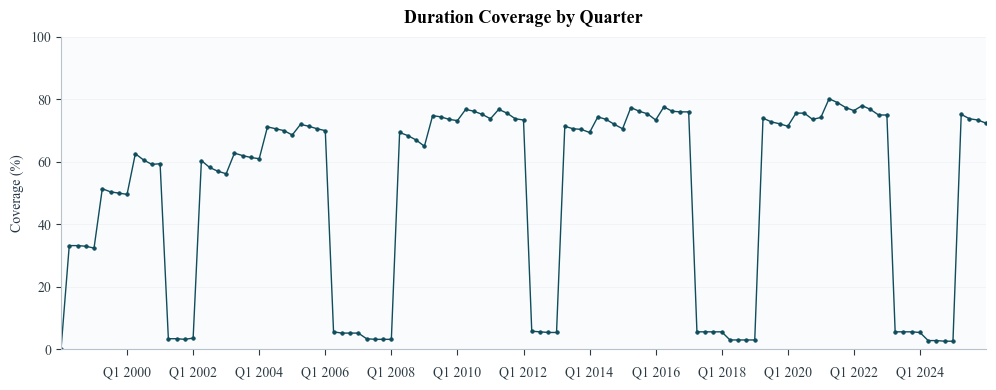

Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/EQDuration_Netpayout.parquet
Saved merged table: EQDuration_Netpayout.parquet
Rows: 56,500
Columns: 45


In [13]:
# ============================================================
# STEP 7: Map annual duration to quarterly euro500 output
# Mapping rule: duration from year t is assigned to euro500 year t+1 (Q1-Q4).
# ============================================================

# Load base quarterly panel (mapping target)
base_np = base_euro500.copy()

if "firm_id" not in base_np.columns:
    raise KeyError("euro500 must contain firm_id")

base_np["firm_id"] = base_np["firm_id"].astype(str).str.strip()

# Ensure merge key year exists on base panel
if "year" not in base_np.columns:
    if "date" in base_np.columns:
        base_np["date"] = pd.to_datetime(base_np["date"], errors="coerce")
        base_np["year"] = base_np["date"].dt.year
    elif "effective_date" in base_np.columns:
        base_np["effective_date"] = pd.to_datetime(base_np["effective_date"], errors="coerce")
        base_np["year"] = base_np["effective_date"].dt.year
    else:
        raise KeyError("euro500 needs year, date, or effective_date")

base_np["year"] = pd.to_numeric(base_np["year"], errors="coerce")
base_np = base_np.dropna(subset=["firm_id", "year"]).copy()
base_np["year"] = base_np["year"].astype(int)

# Prepare annual state/duration table from state_panel
if "firm_id" not in state_panel.columns or "year" not in state_panel.columns:
    raise KeyError("state_panel must contain firm_id and year")

state_merge = state_panel.copy()
state_merge["firm_id"] = state_merge["firm_id"].astype(str).str.strip()
state_merge["year"] = pd.to_numeric(state_merge["year"], errors="coerce")
state_merge = state_merge.dropna(subset=["firm_id", "year"]).copy()
state_merge["year"] = state_merge["year"].astype(int)

# Keep one row per firm-year from state panel
state_cols_pref = [
    "Duration_NP", "discount_rate_NP", "pv_check", "TV_share",
    "bm", "py", "sy", "beg", "ag", "sg", "csprof", "roe", "gp", "lev", "blev", "cash"
]
state_cols = [c for c in state_cols_pref if c in state_merge.columns]
state_merge = (
    state_merge[["firm_id", "year"] + state_cols]
    .drop_duplicates(subset=["firm_id", "year"], keep="last")
)

# Mapping rule: duration_year=t -> map_year=t+1
state_merge = state_merge.rename(columns={"year": "duration_year"})
state_merge["map_year"] = state_merge["duration_year"] + 1

# Merge annual duration/state metrics into quarterly base panel
out = base_np.merge(
    state_merge,
    left_on=["firm_id", "year"],
    right_on=["firm_id", "map_year"],
    how="left",
    validate="m:1"
)


# Quarterly coverage analysis: share of rows with a valid duration
if "Duration_NP" in out.columns:
    cov = out.copy()

    if "quarter" in cov.columns:
        cov["quarter_key"] = cov["quarter"].astype(str)
    elif "date" in cov.columns:
        cov["quarter_key"] = pd.to_datetime(cov["date"], errors="coerce").dt.to_period("Q").astype(str)
    elif "effective_date" in cov.columns:
        cov["quarter_key"] = pd.to_datetime(cov["effective_date"], errors="coerce").dt.to_period("Q").astype(str)
    else:
        cov["quarter_key"] = np.nan

    quarter_cov = (
        cov.dropna(subset=["quarter_key"])
        .groupby("quarter_key", observed=False)
        .agg(
            n_total=("Duration_NP", "size"),
            n_with_duration=("Duration_NP", lambda s: s.notna().sum())
        )
        .reset_index()
    )
    quarter_cov["coverage_pct"] = 100.0 * quarter_cov["n_with_duration"] / quarter_cov["n_total"]
    quarter_cov = quarter_cov.sort_values("quarter_key").reset_index(drop=True)
    quarter_cov["quarter_period"] = pd.PeriodIndex(quarter_cov["quarter_key"], freq="Q")

    print("\nQuarterly coverage (Duration_NP mapped with t -> t+1):")
    print(f"Overall coverage: {out['Duration_NP'].notna().mean():.2%}")
    display(quarter_cov.round(2))

    x_pos = np.arange(len(quarter_cov))
    max_tick_year = quarter_cov["quarter_period"].max().year
    tick_periods = [
        pd.Period(f"{year}Q1", freq="Q")
        for year in range(2000, max_tick_year + 1, 2)
        if year < 2026
    ]
    tick_mask = quarter_cov["quarter_period"].isin(tick_periods)
    tick_idx = np.flatnonzero(tick_mask)
    if len(tick_idx) == 0 and len(quarter_cov) > 0:
        tick_idx = np.array([0])

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(
        x_pos,
        quarter_cov["coverage_pct"],
        color=COLORS["primary"],
        marker="o",
        markersize=2.5,
        linewidth=1.0,
        markerfacecolor=COLORS["primary"],
        markeredgecolor=COLORS["primary"],
        markeredgewidth=0.6,
    )
    ax.set_title("Duration Coverage by Quarter")
    ax.set_xlabel("")
    ax.set_ylabel("Coverage (%)")
    ax.set_ylim(0, 100)
    ax.set_xticks(tick_idx)
    ax.set_xticklabels([f"Q{p.quarter} {p.year}" for p in quarter_cov.loc[tick_idx, "quarter_period"]])
    ax.tick_params(axis="x", rotation=0, length=4, width=0.8, pad=8)
    for label in ax.get_xticklabels():
        label.set_ha("center")
    style_axes(ax)
    plt.tight_layout()
    plt.show()
else:
    quarter_cov = pd.DataFrame()

# Save output parquet (as requested)
save_parquet(out, "EQDuration_Netpayout")

print("Saved merged table: EQDuration_Netpayout.parquet")
print(f"Rows: {len(out):,}")
print(f"Columns: {len(out.columns):,}")


## 9. Diagnostics of Duration_NP

Single consolidated diagnostics block (distribution, correlations, cross-sectional checks, robust visualization, and floor-vs-non-floor comparison).



1. Basic Duration Distribution
count    7323.000000
mean       22.127414
std         2.423201
min         4.207703
1%         16.412299
5%         18.771455
50%        21.969549
95%        25.812842
99%        28.531113
max        57.376317
Name: Duration_NP, dtype: float64

NaN share: 0.5656068335508364
Share Duration_NP > 100: 0.00%
Share Duration_NP > 200: 0.00%
Share discount_rate_NP <= beg_ss+1bp: 0.04%
Share discount_rate_NP <= 1%: 0.00%

2. Correlations with Key Variables


,Duration_NP,bm,py,ag,beg,roe,csprof
Duration_NP,1.000,-0.681,-0.111,0.208,-0.035,-0.095,-0.248
bm,-0.681,1.000,0.054,-0.183,-0.120,-0.203,-0.113
py,-0.111,0.054,1.000,-0.234,-0.361,0.082,0.141
ag,0.208,-0.183,-0.234,1.000,0.652,0.161,0.324
beg,-0.035,-0.120,-0.361,0.652,1.000,0.307,0.646
roe,-0.095,-0.203,0.082,0.161,0.307,1.000,0.444
csprof,-0.248,-0.113,0.141,0.324,0.646,0.444,1.000



3. Duration by BM Quintiles


,Duration_NP
bm,
"(-4.164000000000001, -1.235]",24.7050
"(-1.235, -0.757]",22.7392
"(-0.757, -0.357]",21.6209
"(-0.357, 0.0406]",20.6559
"(0.0406, 1.55]",20.1380



4. Duration by Asset Growth Quintiles


,Duration_NP
ag,
"(-0.761, -0.0223]",21.7562
"(-0.0223, 0.0323]",21.6611
"(0.0323, 0.0829]",21.8018
"(0.0829, 0.173]",22.3064
"(0.173, 1.936]",23.1576



5. Duration by Payout Yield Quintiles


,Duration_NP
py,
"(-0.601, 0.0]",22.4604
"(0.0, 0.0136]",22.8476
"(0.0136, 0.0271]",22.1370
"(0.0271, 0.048]",21.7304
"(0.048, 0.357]",21.5481



6. Duration Histogram


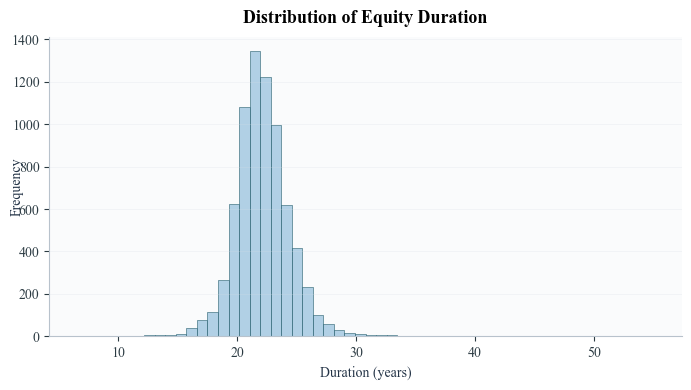


7. Duration vs BM: Robust Visual Diagnostic
Share with Duration_NP in [16, 20]: 13.27%


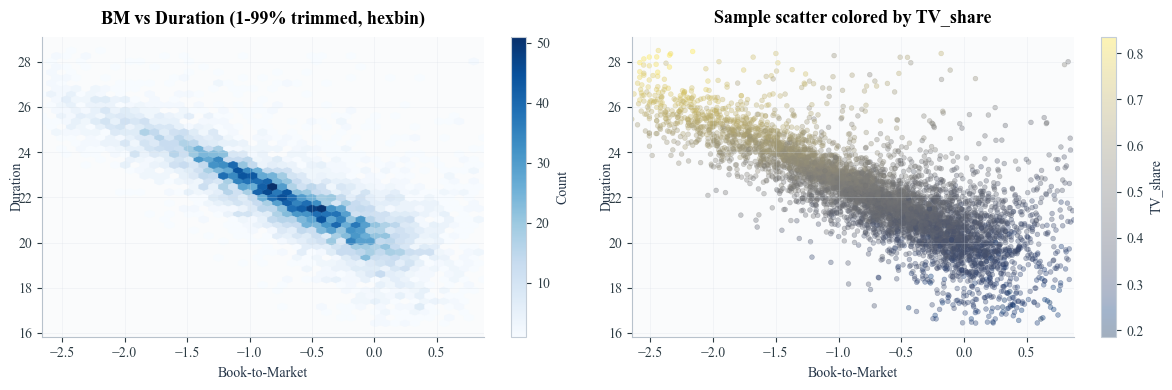

In [14]:
with pd.option_context("display.max_rows", 200, "display.max_columns", None, "display.width", 200):


    print("\n==============================")
    print("1. Basic Duration Distribution")
    print("==============================")

    print(state_panel["Duration_NP"].describe(percentiles=[0.01,0.05,0.5,0.95,0.99]))
    print("\nNaN share:", state_panel["Duration_NP"].isna().mean())

    d_tmp = pd.to_numeric(state_panel["Duration_NP"], errors="coerce")
    d_tmp = d_tmp[np.isfinite(d_tmp)]
    if len(d_tmp) > 0:
        print(f"Share Duration_NP > 100: {(d_tmp > 100).mean():.2%}")
        print(f"Share Duration_NP > 200: {(d_tmp > 200).mean():.2%}")

    if "discount_rate_NP" in state_panel.columns:
        dr = pd.to_numeric(state_panel["discount_rate_NP"], errors="coerce")
        dr_valid = dr.dropna()
        if len(dr_valid) > 0:
            near_gss = (dr_valid <= (beg_ss + 1e-3)).mean()
            near_low = (dr_valid <= 0.01).mean()
            print(f"Share discount_rate_NP <= beg_ss+1bp: {near_gss:.2%}")
            print(f"Share discount_rate_NP <= 1%: {near_low:.2%}")


    print("\n==============================")
    print("2. Correlations with Key Variables")
    print("==============================")

    vars_check = [
        "Duration_NP",
        "bm",
        "py",
        "ag",
        "beg",
        "roe",
        "csprof"
    ]

    corr = state_panel[vars_check].corr().round(3)
    display(corr)


    print("\n==============================")
    print("3. Duration by BM Quintiles")
    print("==============================")

    bm_test = state_panel.groupby(
        pd.qcut(state_panel["bm"], 5), observed=False
    )["Duration_NP"].mean()

    display(bm_test.to_frame("Duration_NP").round(4))


    print("\n==============================")
    print("4. Duration by Asset Growth Quintiles")
    print("==============================")

    growth_test = state_panel.groupby(
        pd.qcut(state_panel["ag"], 5), observed=False
    )["Duration_NP"].mean()

    display(growth_test.to_frame("Duration_NP").round(4))


    print("\n==============================")
    print("5. Duration by Payout Yield Quintiles")
    print("==============================")

    payout_test = state_panel.groupby(
        pd.qcut(state_panel["py"], 5), observed=False
    )["Duration_NP"].mean()

    display(payout_test.to_frame("Duration_NP").round(4))


    print("\n==============================")
    print("6. Duration Histogram")
    print("==============================")

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(
        state_panel["Duration_NP"].dropna(),
        bins=60,
        color=COLORS["blue_light"],
        edgecolor=COLORS["primary"],
        alpha=0.9,
    )
    ax.set_title("Distribution of Equity Duration")
    ax.set_xlabel("Duration (years)")
    ax.set_ylabel("Frequency")
    style_axes(ax)
    plt.tight_layout()
    plt.show()


    print("\n==============================")
    print("7. Duration vs BM: Robust Visual Diagnostic")
    print("==============================")

    plot_df = state_panel[["bm", "Duration_NP", "TV_share", "discount_rate_NP"]].dropna(subset=["bm", "Duration_NP"]).copy()

    if len(plot_df) == 0:
        print("No valid observations for bm vs Duration_NP plot.")
    else:
        # Report concentration in the visually suspicious low-duration band.
        band_share = plot_df["Duration_NP"].between(16, 20).mean()
        print(f"Share with Duration_NP in [16, 20]: {band_share:.2%}")

        # Trim only for visualization (core diagnostics still use full sample).
        bm_lo, bm_hi = plot_df["bm"].quantile([0.01, 0.99])
        dur_lo, dur_hi = plot_df["Duration_NP"].quantile([0.01, 0.99])
        plot_trim = plot_df[
            plot_df["bm"].between(bm_lo, bm_hi)
            & plot_df["Duration_NP"].between(dur_lo, dur_hi)
        ].copy()

        sample_n = min(6000, len(plot_trim))
        plot_sample = plot_trim.sample(n=sample_n, random_state=42) if sample_n > 0 else plot_trim

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        hb = axes[0].hexbin(
            plot_trim["bm"],
            plot_trim["Duration_NP"],
            gridsize=45,
            mincnt=1,
            cmap="Blues"
        )
        axes[0].set_title("BM vs Duration (1-99% trimmed, hexbin)")
        axes[0].set_xlabel("Book-to-Market")
        axes[0].set_ylabel("Duration")
        style_axes(axes[0], grid_axis="both")
        cbar_left = fig.colorbar(hb, ax=axes[0], label="Count")
        cbar_left.outline.set_edgecolor("#C4CDD7")

        if "TV_share" in plot_sample.columns and plot_sample["TV_share"].notna().any():
            sc = axes[1].scatter(
                plot_sample["bm"],
                plot_sample["Duration_NP"],
                c=plot_sample["TV_share"],
                s=12,
                alpha=0.35,
                cmap="cividis"
            )
            cbar_right = fig.colorbar(sc, ax=axes[1], label="TV_share")
            cbar_right.outline.set_edgecolor("#C4CDD7")
            axes[1].set_title("Sample scatter colored by TV_share")
        else:
            axes[1].scatter(
                plot_sample["bm"],
                plot_sample["Duration_NP"],
                s=12,
                alpha=0.35,
                color=COLORS["accent"],
            )
            axes[1].set_title("Sample scatter")

        axes[1].set_xlabel("Book-to-Market")
        axes[1].set_ylabel("Duration")
        style_axes(axes[1], grid_axis="both")

        plt.tight_layout()
        plt.show()


In [15]:
# ============================================================
# STEP 7: Diagnostic - Terminal Value Contribution
# ============================================================

def compute_tv_share(row, H=15, r=0.08):

    path_df = forecast_book_equity_and_payouts(row, H=H)

    TV_H, PO_H_plus_1 = add_terminal_value(
        path_df,
        r=r,
        g_ss=g_ss,
        po_be_ss=po_be_ss
    )

    pv_df, total_pv, PV_TV = present_value_weights(
        path_df,
        r=r,
        TV_H=TV_H
    )

    if not np.isfinite(total_pv) or total_pv <= 0:
        return np.nan

    tv_share = PV_TV / total_pv

    return tv_share


state_panel["TV_share"] = state_panel.apply(
    compute_tv_share,
    axis=1
)

print("\n==============================")
print("Terminal Value Share")
print("==============================")

print(
    state_panel["TV_share"].describe(
        percentiles=[0.01,0.05,0.5,0.95,0.99]
    )
)


Terminal Value Share
count    7323.000000
mean        0.865482
std         0.028709
min         0.744970
1%          0.818528
5%          0.833263
50%         0.859029
95%         0.915512
99%         0.952526
max         1.230363
Name: TV_share, dtype: float64


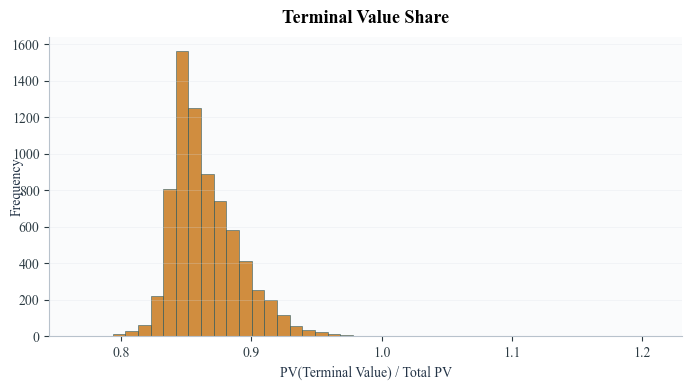

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(
    state_panel["TV_share"].dropna(),
    bins=50,
    color=COLORS["orange"],
    edgecolor=COLORS["primary"],
    alpha=0.85,
)
ax.set_title("Terminal Value Share")
ax.set_xlabel("PV(Terminal Value) / Total PV")
ax.set_ylabel("Frequency")
style_axes(ax)
plt.tight_layout()
plt.show()
